In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
import multiprocessing
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
JD0 = 2450000
from emcee.autocorr import integrated_time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner


import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib.patches import Patch
import arviz as az

import logging
logging.getLogger("emcee.autocorr").setLevel(logging.ERROR)

from matplotlib.lines import Line2D

tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()


In [2]:
import tempfile
import shutil
import os
def read_chain(path, burnin, thin, flat=True):
    tmpdir = tempfile.mkdtemp()
    tmp_path = os.path.join(tmpdir, "chain_copy.h5")
    shutil.copy2(path, tmp_path)

    try:
        sampler = emcee.backends.HDFBackend(tmp_path, read_only=True)
        chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
        blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin)
        lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin)
    finally:
        try:
            os.remove(tmp_path)
            os.rmdir(tmpdir)
        except Exception:
            pass

    return chain,  blob,lnprob

In [5]:
def calc_tau(arr):
    taus = []
    for pi in range(arr.shape[2]):
        tau_walkers = []
        for w in range(arr.shape[1]):
            chain = arr[:, w, pi]
            tau = emcee.autocorr.integrated_time(chain[:, None], quiet=True)
            tau_walkers.append(tau.item())
        mean_tau = np.mean(tau_walkers)
        taus.append(mean_tau)
        print(f"param[{pi}] mean τ_int over {arr.shape[1]} walkers = {mean_tau:.2f}")

    return max(taus)

In [3]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [11]:
chain_para, blob_para, lnprob_para = read_chain("/moao42_9/nunota/gapmoe/chain_simu10_para.h5",10000,3500,flat=True)
chain_sta, blob_sta, lnprob_sta = read_chain("/moao42_9/nunota/gapmoe/chain_simu10_sta.h5",10000,3500,flat=True)


In [13]:
def calc_med_err(chain):
    p16, p50, p84 = np.percentile(chain, [16, 50, 84])
    return p50, p84 - p16

In [15]:
tE_med_para, tE_err_para = calc_med_err(chain_para[:,1])
thE_med_para, thE_err_para = calc_med_err(blob_para/chain_para[:,3])
piEN_med_para, piEN_err_para = calc_med_err(chain_para[:,7])
piEE_med_para, piEE_err_para = calc_med_err(chain_para[:,8])

tE_med_sta, tE_err_sta = calc_med_err(chain_sta[:,1])
thE_med_sta, thE_err_sta = calc_med_err(blob_sta/chain_sta[:,3])


In [17]:
argtxt = "./genulens "
argtxt += "l 1.5972674  b -2.1130907 "
argtxt += "vEarthlb 0.48  -0.67 "
argtxt += f"tE {round(tE_med_para,3)} {round(tE_err_para,3)} "
argtxt += f"thetaE {round(thE_med_para,3)} {round(thE_err_para,3)} "
argtxt_para = argtxt + f"piEN {round(piEN_med_para,3)} {round(piEN_err_para,3)} "
argtxt_para += f"piEE {round(piEE_med_para,3)} {round(piEE_err_para,3)} "

argtxt_para += "SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 "
argtxt_para += "> /moao38_7/nunota/gapmoe/test_result/genout/genuout_para_10.dat"

print(argtxt_para+" &")

argtxt = "./genulens "
argtxt += "l 1.5972674  b -2.1130907 "
argtxt += "vEarthlb 0.48  -0.67 "
argtxt += f"tE {round(tE_med_sta,3)} {round(tE_err_sta,3)} "
argtxt += f"thetaE {round(thE_med_sta,3)} {round(thE_err_sta,3)} "

argtxt_wo_para = argtxt+ "SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 "
argtxt_wo_para += "> /moao38_7/nunota/gapmoe/test_result/genout/genuout_static_10.dat"

print("\n")
print(argtxt_wo_para+" &")
print("\n")


./genulens l 1.5972674  b -2.1130907 vEarthlb 0.48  -0.67 tE 29.729 0.686 thetaE 0.297 0.079 piEN -0.934 2.781 piEE -0.114 0.501 SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 > /moao38_7/nunota/gapmoe/test_result/genout/genuout_para_10.dat &


./genulens l 1.5972674  b -2.1130907 vEarthlb 0.48  -0.67 tE 29.589 0.602 thetaE 0.297 0.075 SMALLGAMMA 0 VERBOSITY 3 UNIFORM 0 NlikeMIN 1e+5 > /moao38_7/nunota/gapmoe/test_result/genout/genuout_static_10.dat &




In [19]:
names = "wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L     K_L iS iL fREM".split()


def load_genulens(path):
    genulens_out = np.genfromtxt(path,names=names)
    wtj = genulens_out["wtj"] / np.sum(genulens_out["wtj"])
    ML_genu = genulens_out["M_L"]
    DL_genu = genulens_out["D_L"] * 1e-3
    DS_genu = genulens_out["D_S"] * 1e-3
    muN_genu = genulens_out["mu_rel"] * genulens_out["pi_EN"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[0]
    muE_genu = genulens_out["mu_rel"] * genulens_out["pi_EE"] / genulens_out["pi_E"] + genulens_out["theta_E"] * genulens_out["pi_E"]  * vEarth[1]

    return np.array(wtj), np.array([ML_genu,DL_genu,DS_genu,muN_genu,muE_genu ]).T


In [20]:
wtj_para, genuout_para = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/genuout_para_10.dat")
wtj_sta, genuout_sta = load_genulens("/moao38_7/nunota/gapmoe/test_result/genout/genuout_static_10.dat")

In [21]:
ranges = [
    (-0.3, 1.8),      
    (1, 11),      
    (3, 18),     
    (-15, 15),         
    (-15, 15),         
]


def cut_genuout(genuout,wtj):
    genuout = genuout[np.where((genuout[:,0]>ranges[0][0])&(genuout[:,0]<ranges[0][1]))]
    genuout = genuout[np.where((genuout[:,1]>ranges[1][0])&(genuout[:,1]<ranges[1][1]))]
    genuout = genuout[np.where((genuout[:,2]>ranges[2][0])&(genuout[:,2]<ranges[2][1]))]
    genuout = genuout[np.where((genuout[:,3]>ranges[3][0])&(genuout[:,3]<ranges[3][1]))]
    genuout = genuout[np.where((genuout[:,4]>ranges[4][0])&(genuout[:,4]<ranges[4][1]))]
    
    wtj = wtj[np.where((genuout[:,0]>ranges[0][0])&(genuout[:,0]<ranges[0][1]))]
    wtj = wtj[np.where((genuout[:,1]>ranges[1][0])&(genuout[:,1]<ranges[1][1]))]
    wtj = wtj[np.where((genuout[:,2]>ranges[2][0])&(genuout[:,2]<ranges[2][1]))]
    wtj = wtj[np.where((genuout[:,3]>ranges[3][0])&(genuout[:,3]<ranges[3][1]))]
    wtjt = wtj[np.where((genuout[:,4]>ranges[4][0])&(genuout[:,4]<ranges[4][1]))]
    
    return genuout, wtj
    
genuout_para,wtj_para = cut_genuout(genuout_para,wtj_para)

genuout_sta,wtj_sta = cut_genuout(genuout_sta,wtj_sta)

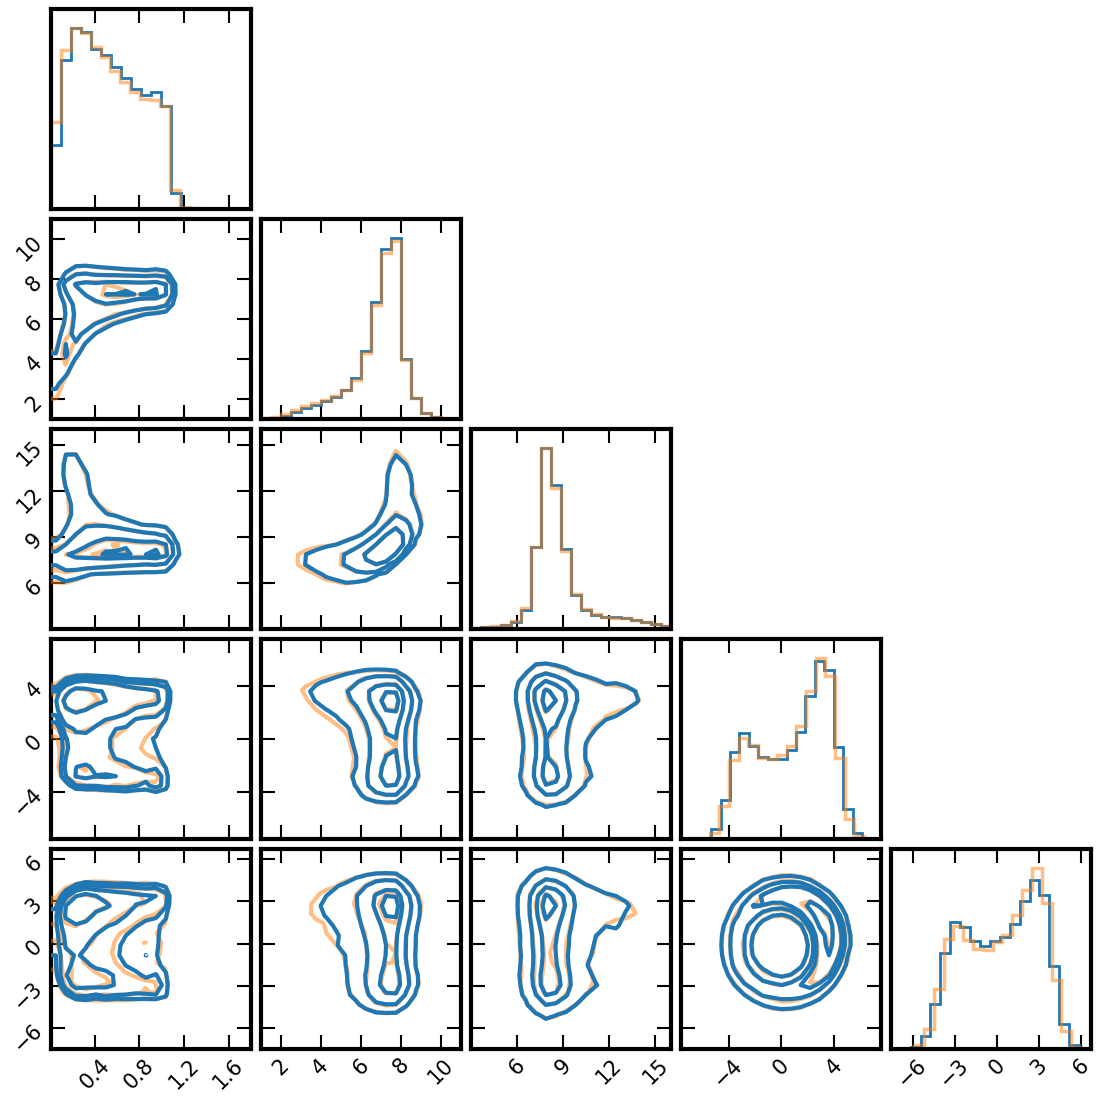

In [22]:
fig = corner.corner(genuout_para,
                    weights=wtj_para,
            fill_contours=False, plot_density=False,
              color="C0",     hist_kwargs={"density": True, "linewidth": 2, "alpha": 1},
            contour_kwargs={"zorder": 6, "linewidths": 3,"alpha":1,"zorder":10},
            show_titles=False,
            plot_datapoints=False, smooth=1.0/2)

corner.corner(
    genuout_sta,
    weights=wtj_sta,
    fig=fig,
    color="C1",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 0.5},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3,"alpha":0.5},
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0/2
)

plt.show()